# Vol Overlay — Implementation Comparison

Loads trades from `results/vol_overlay_trades.csv` (winning variant from backtest).

**Architecture:** Single-sleeve SPY, daily rebalance. Exposure multiplier already baked into `pct_return_gross`.

**Sizing:** Simple bet across leverage levels (1×, 1.5×, 2×, 3×). Kelly is not meaningful here — per-day edge is ~4bps and Kelly would size on that tiny edge regardless of the trade's actual risk; the result is either near-cash (fractional Kelly) or identical to leverage (since Sharpe is scale-invariant).

**Key comparison: overlay vs SPY+leverage at matched drawdown.**
If overlay at Nx gives higher CAGR than SPY at Mx when DD is similar, the overlay is adding real risk-adjusted value beyond what leverage alone could achieve.

## 1. Setup

In [17]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Vol Overlay"
SAVE_NAME     = "vol_overlay"

pd.set_option("display.max_columns", None)

## 2. Load Standardized Trades

In [18]:
trades = pd.read_csv(f"results/{SAVE_NAME}_trades.csv",
                      parse_dates=["entry_time", "exit_time"])
print(f"Loaded {len(trades)} trades")
print(f"Period: {trades['entry_time'].iloc[0].date()} → {trades['exit_time'].iloc[-1].date()}")

# Sanity: schema check
STD_COLS = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
missing = [c for c in STD_COLS if c not in trades.columns]
assert not missing, f"Missing standard columns: {missing}"
print(f"Schema OK — {len(STD_COLS)} standard columns present")
print(f"Avg gross per-day return: {trades['pct_return_gross'].mean()*100:.4f}%")

Loaded 2573 trades
Period: 2016-01-05 → 2026-03-31
Schema OK — 9 standard columns present
Avg gross per-day return: 0.0425%


## 3. Simple Leverage Sweep

In [19]:
def compute_stats(eq, ret, starting_capital=STARTING_CAPITAL):
    daily_r = ret.dropna()
    sharpe = daily_r.mean() / daily_r.std() * np.sqrt(252) if daily_r.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1] / starting_capital) ** (1/years) - 1) * 100 if years > 0 else 0
    tot = (eq.iloc[-1] / starting_capital - 1) * 100
    return {"total_return": round(tot, 1), "cagr": round(cagr, 2),
            "sharpe": round(sharpe, 2), "max_dd": round(max_dd, 1)}

def run_overlay(trades, leverage=1.0, label=""):
    r = trades.set_index("entry_time")["pct_return_gross"] * leverage
    eq = STARTING_CAPITAL * (1 + r).cumprod()
    return {"label": label, "daily_equity": eq, "daily_returns": r,
            "stats": compute_stats(eq, r)}

def run_spy_lev(spy_ret, leverage=1.0, label=""):
    r = spy_ret * leverage
    eq = STARTING_CAPITAL * (1 + r).cumprod()
    return {"label": label, "daily_equity": eq, "daily_returns": r,
            "stats": compute_stats(eq, r)}

def print_comparison(results):
    print(f"{'Label':<35} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
    print("-" * 77)
    for r in results:
        s = r["stats"]
        print(f"{r['label']:<35} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} "
              f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

## 4. Overlay vs SPY at Each Leverage Level

Two strategies, 4 leverage levels each, side by side.

In [20]:
# SPY benchmark returns
spy_price = trades.set_index("entry_time")["entry_price"]
spy_ret = spy_price.pct_change().dropna()

LEVERAGES = [1.0, 1.5, 2.0, 3.0]

overlay_results = []
spy_results = []
for lev in LEVERAGES:
    overlay_results.append(run_overlay(trades, leverage=lev, label=f"Overlay {lev}x"))
    spy_results.append(run_spy_lev(spy_ret, leverage=lev, label=f"SPY B&H {lev}x"))

print("INTERLEAVED COMPARISON — Overlay vs SPY at same leverage:\n")
interleaved = []
for o, s in zip(overlay_results, spy_results):
    interleaved.append(o)
    interleaved.append(s)
print_comparison(interleaved)

INTERLEAVED COMPARISON — Overlay vs SPY at same leverage:

Label                                  TotRet%    CAGR%   Sharpe   MaxDD%
-----------------------------------------------------------------------------
Overlay 1.0x                             179.4    10.56     0.94    -17.7
SPY B&H 1.0x                             268.0    13.59     0.81    -33.8
Overlay 1.5x                             344.1    15.69     0.94    -25.9
SPY B&H 1.5x                             525.9    19.64     0.81    -47.2
Overlay 2.0x                             582.5    20.65     0.94    -33.7
SPY B&H 2.0x                             881.3    25.02     0.81    -58.5
Overlay 3.0x                           1,356.1    29.92     0.94    -47.7
SPY B&H 3.0x                           1,782.0    33.23     0.81    -75.6


## 5. Matched-Drawdown Comparison

Pair each overlay leverage level with the SPY leverage that gives roughly the same drawdown. This is the honest test: does the overlay add value beyond what leverage alone could achieve?

In [21]:
# Find SPY leverage that matches each overlay MaxDD
print(f"{'Overlay':<18} {'SPY-matched':<20} {'Overlay CAGR':>14} {'SPY CAGR':>12} {'CAGR edge':>12}")
print("-" * 82)

for o in overlay_results:
    target_dd = o["stats"]["max_dd"]
    # Find the SPY leverage whose MaxDD is closest to target
    best_spy = min(spy_results, key=lambda s: abs(s["stats"]["max_dd"] - target_dd))
    edge = o["stats"]["cagr"] - best_spy["stats"]["cagr"]
    print(f"{o['label']:<18} {best_spy['label']:<20} "
          f"(DD {o['stats']['max_dd']:>5.1f}%) "
          f"{o['stats']['cagr']:>14.2f} {best_spy['stats']['cagr']:>12.2f} {edge:>+11.2f}")

Overlay            SPY-matched            Overlay CAGR     SPY CAGR    CAGR edge
----------------------------------------------------------------------------------
Overlay 1.0x       SPY B&H 1.0x         (DD -17.7%)          10.56        13.59       -3.03
Overlay 1.5x       SPY B&H 1.0x         (DD -25.9%)          15.69        13.59       +2.10
Overlay 2.0x       SPY B&H 1.0x         (DD -33.7%)          20.65        13.59       +7.06
Overlay 3.0x       SPY B&H 1.5x         (DD -47.7%)          29.92        19.64      +10.28


## 6. Equity Curves

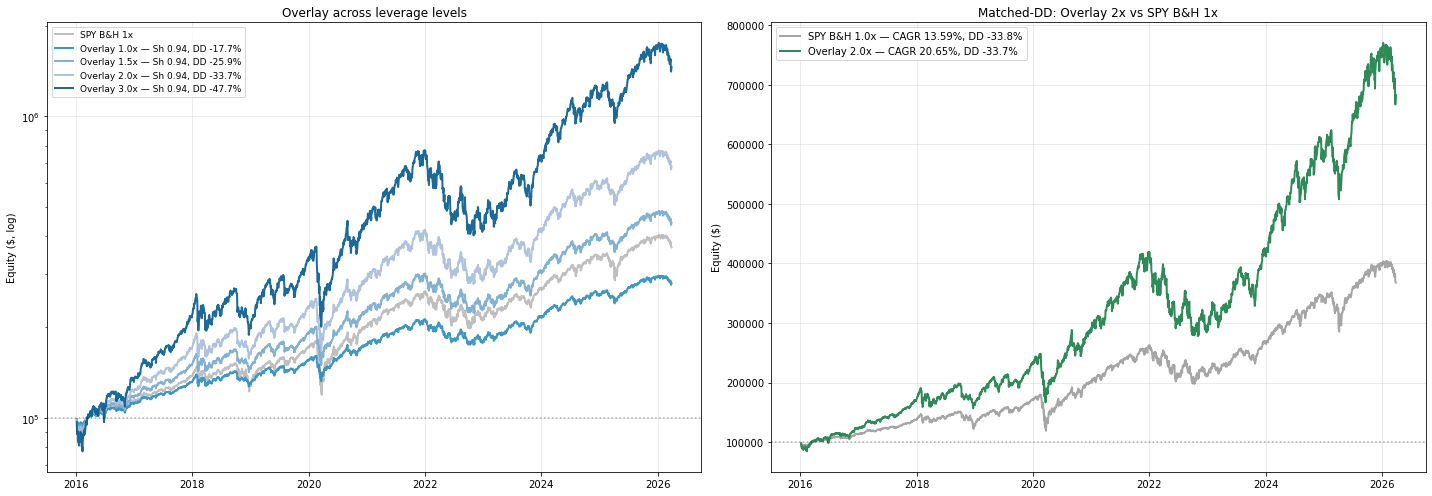

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: overlay at all leverage levels + SPY 1x reference
ax = axes[0]
ax.plot(spy_results[0]["daily_equity"].index.to_numpy(),
        spy_results[0]["daily_equity"].values,
        color="gray", alpha=0.5, linewidth=2, label=f"SPY B&H 1x")
colors_over = ["#2b8cbe", "#74a9cf", "#a6bddb", "#045a8d"]
for r, c in zip(overlay_results, colors_over):
    s = r["stats"]
    ax.plot(r["daily_equity"].index.to_numpy(), r["daily_equity"].values,
            color=c, linewidth=2, alpha=0.9,
            label=f"{r['label']} — Sh {s['sharpe']}, DD {s['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_yscale("log")
ax.set_title("Overlay across leverage levels")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($, log)")

# Right: matched-DD comparison — Overlay 2x vs SPY 1x (similar DD ~33%)
ax = axes[1]
o2 = overlay_results[2]  # 2x
s1 = spy_results[0]      # 1x
ax.plot(s1["daily_equity"].index.to_numpy(), s1["daily_equity"].values,
        color="gray", linewidth=2, alpha=0.7,
        label=f"{s1['label']} — CAGR {s1['stats']['cagr']}%, DD {s1['stats']['max_dd']}%")
ax.plot(o2["daily_equity"].index.to_numpy(), o2["daily_equity"].values,
        color="seagreen", linewidth=2,
        label=f"{o2['label']} — CAGR {o2['stats']['cagr']}%, DD {o2['stats']['max_dd']}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("Matched-DD: Overlay 2x vs SPY B&H 1x")
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_ylabel("Equity ($)")

plt.tight_layout(); plt.show()

## 7. Save Implementation Summary

In [23]:
import os, json

os.makedirs("results", exist_ok=True)

all_results = overlay_results + spy_results

def _key(label):
    return (label.lower().replace(" ", "_").replace("×", "x")
             .replace(".", "p"))

impl_summary = {}
for r in all_results:
    k = _key(r["label"])
    impl_summary[k] = dict(r["stats"])
    impl_summary[k]["label"] = r["label"]

# Matched-DD edges
matched_dd_edges = {}
for o in overlay_results:
    target_dd = o["stats"]["max_dd"]
    best_spy = min(spy_results, key=lambda s: abs(s["stats"]["max_dd"] - target_dd))
    matched_dd_edges[o["label"]] = {
        "matched_to": best_spy["label"],
        "overlay_dd": o["stats"]["max_dd"],
        "spy_dd": best_spy["stats"]["max_dd"],
        "overlay_cagr": o["stats"]["cagr"],
        "spy_cagr": best_spy["stats"]["cagr"],
        "cagr_edge": round(o["stats"]["cagr"] - best_spy["stats"]["cagr"], 2),
    }
impl_summary["_matched_dd_edges"] = matched_dd_edges

# Best by Sharpe among overlay results (SPY Sharpe is identical across leverage, so just pick one)
best = max(overlay_results, key=lambda r: r["stats"]["sharpe"])
impl_summary["_recommended"] = best["label"]
print(f"Best by Sharpe: {best['label']} — Sh {best['stats']['sharpe']}, "
      f"DD {best['stats']['max_dd']}%, CAGR {best['stats']['cagr']}%")

# Best by matched-DD edge
best_edge_label = max(matched_dd_edges, key=lambda k: matched_dd_edges[k]["cagr_edge"])
best_edge = matched_dd_edges[best_edge_label]
impl_summary["_best_matched_dd_edge"] = best_edge_label
print(f"\nBest matched-DD edge: {best_edge_label} vs {best_edge['matched_to']}")
print(f"  At DD ~{best_edge['overlay_dd']:.1f}%: overlay CAGR {best_edge['overlay_cagr']:.2f}% "
      f"vs SPY {best_edge['spy_cagr']:.2f}% (+{best_edge['cagr_edge']:.2f}pp)")

with open(f"results/{SAVE_NAME}_implementations.json", "w") as f:
    json.dump(impl_summary, f, indent=2)
print(f"\nSaved → results/{SAVE_NAME}_implementations.json")

# Save equity curves
eq_dir = f"results/{SAVE_NAME}_daily_equity"
os.makedirs(eq_dir, exist_ok=True)
for r in all_results:
    r["daily_equity"].to_csv(f"{eq_dir}/{_key(r['label'])}.csv")
print(f"Saved {len(all_results)} daily equity curves → {eq_dir}/")

Best by Sharpe: Overlay 1.0x — Sh 0.94, DD -17.7%, CAGR 10.56%

Best matched-DD edge: Overlay 3.0x vs SPY B&H 1.5x
  At DD ~-47.7%: overlay CAGR 29.92% vs SPY 19.64% (+10.28pp)

Saved → results/vol_overlay_implementations.json
Saved 8 daily equity curves → results/vol_overlay_daily_equity/
